In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms,models
from torch.utils.data import DataLoader

In [3]:
# creating the image transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

transform_val = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
# creating the Datasets and the DataLoaders
import os
# 1. Get the current directory of the notebook
notebook_dir = os.getcwd()

# 2. Construct the path to the root 'data' folder
# '..' moves up one level from 'notebooks' to your main project folder
train_path = os.path.join(notebook_dir, '..', 'data', 'raw', 'Water_images', 'train')
val_path = os.path.join(notebook_dir, '..', 'data', 'raw', 'Water_images', 'valid')

# 3. Use these absolute paths in your dataset loader
train_data = datasets.ImageFolder(root=train_path, transform=transform)
val_data = datasets.ImageFolder(root=val_path, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

print(f"Successfully loaded {len(train_data)} training images.")

train_loader = DataLoader(train_data,batch_size = 32, shuffle=True)
val_loader = DataLoader(val_data,batch_size = 32, shuffle=False)


Successfully loaded 1071 training images.


In [5]:
print("Train images:", len(train_data))
print("Validation images:", len(val_data))

Train images: 1071
Validation images: 101


In [6]:
# verifiying whether the datasets is loaded correctly
print(train_data.classes)

['Bersih', 'Keruh', 'Kotor']


In [7]:
# loading the pretrained MobileNetV2 model
model = models.mobilenet_v2(pretrained=True)

c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [8]:
model.classifier[1] = nn.Linear(model.last_channel, 3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [9]:
from collections import Counter
class_counts = Counter(train_data.targets)

total = sum(class_counts.values())

weights = [
    total/class_counts[0],
    total/class_counts[1],
    total/class_counts[2]
]

weights = torch.tensor(weights).float().to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

In [10]:
# training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# training loop

epochs = 15
for epoch in range(epochs):
    model.train()
    running_loss =0

    for images,labels in train_loader :
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss}")

Epoch 1/15, Loss: 8.170761225745082
Epoch 2/15, Loss: 0.674150025472045
Epoch 3/15, Loss: 0.1584160311613232
Epoch 4/15, Loss: 0.11791450751479715
Epoch 5/15, Loss: 0.06787934916792437
Epoch 6/15, Loss: 0.06711669577634893
Epoch 7/15, Loss: 0.04689785517985001
Epoch 8/15, Loss: 0.0783294352440862
Epoch 9/15, Loss: 0.039882309720269404
Epoch 10/15, Loss: 0.23216903647698928
Epoch 11/15, Loss: 0.14399287512060255
Epoch 12/15, Loss: 0.02442377177067101
Epoch 13/15, Loss: 0.07625572380493395
Epoch 14/15, Loss: 0.14178909482143354
Epoch 15/15, Loss: 0.19657049352827016


In [11]:
# validating the model accuracy
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Validation Accuracy:", correct/total)

Validation Accuracy: 1.0


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Confusion Matrix")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report")
print(classification_report(all_labels, all_preds))

Confusion Matrix
[[66  0  0]
 [ 0 13  0]
 [ 0  0 22]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        66
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        22

    accuracy                           1.00       101
   macro avg       1.00      1.00      1.00       101
weighted avg       1.00      1.00      1.00       101



In [13]:
from collections import Counter

print(Counter(train_data.targets))
print(Counter(val_data.targets))

Counter({0: 624, 1: 240, 2: 207})
Counter({0: 66, 2: 22, 1: 13})


In [14]:
import matplotlib.pyplot as plt

model.eval()

images, labels = next(iter(val_loader))
images = images.to(device)

outputs = model(images)
_, preds = torch.max(outputs,1)

print("Predicted:", preds[:10])
print("Actual:", labels[:10])

Predicted: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
Actual: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [17]:
import os

# Check your current working directory
print(os.getcwd())
torch.save(model.state_dict(), "../models/water_cnn_model.pth")

d:\Water_Quality\notebooks


              precision    recall  f1-score   support

      Bersih       1.00      1.00      1.00        66
       Keruh       1.00      1.00      1.00        13
       Kotor       1.00      1.00      1.00        22

    accuracy                           1.00       101
   macro avg       1.00      1.00      1.00       101
weighted avg       1.00      1.00      1.00       101



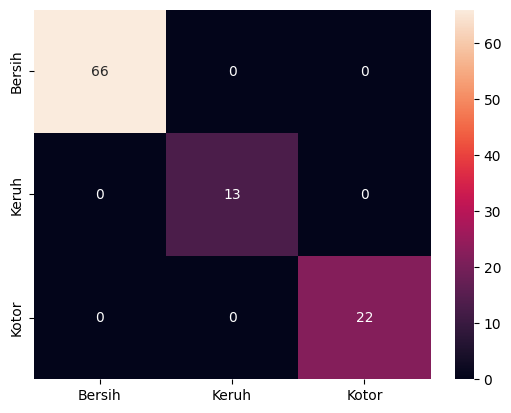

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Define class names
class_names = train_data.classes

# Run on your validation set
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names)
plt.show()